<!-- sablier-flow:download-banner -->

> **Download this notebook:** [`03_memorization_audit.ipynb`](https://raw.githubusercontent.com/sablier-ai/sablier-flow/main/examples/03_memorization_audit.ipynb) (right-click → Save Link As)
> · [View source on GitHub](https://github.com/sablier-ai/sablier-flow/blob/main/examples/03_memorization_audit.ipynb)
> · Or `pip install sablier-flow && sablier-flow notebook` to copy a fresh local copy from the wheel.


# Memorization Audit — Is FLOW synth genuinely new, or just remixed training data?

**The question this notebook answers, falsifiably:** when sablier-flow emits a
synthetic alternative history, is the model *generating* novel paths whose
statistics match training — or is it just *replaying* slightly shuffled
training samples? If FLOW were memorizing, every backtest verdict built on
top of FLOW synth would be a leakage-driven mirage.

**How we measure it (nearest-neighbour distance ratio).** For every synthetic
sample, compute its nearest-neighbour distance to the training set. Compare
the median synthetic-to-training distance against the median
training-to-training distance (with self-pairs excluded from the denominator).
The ratio
$$
R \;=\; \frac{\mathrm{median}_i\,\min_j\,d(\hat{X}_i,\,X_j)}{\mathrm{median}_i\,\min_{j\neq i}\,d(X_i,\,X_j)}
$$
sits in the natural unit of distance ratios — independent of feature scale,
horizon, and number of paths.

**Thresholds (calibrated for financial-returns flow models, not image diffusion):**

| Band              | NN-distance ratio R | Meaning                                                      |
|-------------------|---------------------|--------------------------------------------------------------|
| Healthy (`low`)   | `R > 0.80`           | Synth is roughly as far from train as train is from itself — novel. |
| Suspicious (`medium`) | `0.50 ≤ R ≤ 0.80`   | Synth crowds closer than train-to-train — worth a look.     |
| Memorisation (`high`) | `R < 0.50`           | Synth is markedly closer than training — likely leakage.    |

Why these cutoffs and not the more stringent image-diffusion ones (where R < 0.95 is the standard alarm)? Image memorization means bit-identical training images leak out — the alarm bar is naturally close to 1 because a memorized image is byte-for-byte identical. Financial daily returns are drawn from a noisy continuous distribution, so a perfectly calibrated flow produces synth that lands *within* the training manifold (R < 1 is normal, not pathological). The 0.80 cutoff was set after a customer with nominal coverage (the model's 95% intervals contained reality 95.1% of the time — well-calibrated) was being flagged 'high memorization' at R ≈ 0.84. Those two readings are mutually exclusive — a memorized model has collapsed intervals, not nominal coverage — so the threshold was the bug. Below R ≈ 0.80 the synth genuinely starts to crowd; below R ≈ 0.50 it is closer to training than training is to itself, which is the operational signal of leakage.

**Falsification claim, set up-front:**

> If sablier-flow's joint generator were just remixing training data, its
> NN-distance ratio against the training set would collapse toward zero
> (≪ 0.50 — `'high'` Memorisation). We will sanity-check by computing
> the same ratio for a **trivial replay baseline** that returns shuffled
> training rows. If FLOW's ratio is statistically distinguishable from the
> replay baseline AND lands in the Healthy band, we have failed to
> falsify the model's novelty.

We will report the result whichever way it lands. The replay baseline is the
floor — if FLOW's ratio is anywhere close to it, we ship a Memorisation
verdict and the customer knows to retrain with stronger regularization.


## Operating envelope

> **What this notebook demonstrates:** sablier-flow is generating novel
> synthetic paths whose joint statistics match training, not replaying
> training samples — falsifiably checked against a trivial replay-memorizer
> baseline.
>
> **Where this works best:** multi-asset (3-8 features), daily frequency,
> 5+ years of training data, dependence-heavy strategies.
>
> **Where to be careful:** single-asset, intraday, sparse data, regime-shift
> OOS windows.
>
> **How to validate on your data:** run cells 1-N below with the demo data
> first (verify it reproduces the demo numbers), then swap in your data via
> the final 'Try your own data' cell.


## Setup

We need `sablier-flow` (the SDK), `numpy` + `scipy` for the replay-baseline
NN distance computation, and `matplotlib` for the per-cell verdict
visualisation.


In [1]:
# One-time install. Pinned to a 1.0.17+ wheel for
# `ValidationReport.memorization_risk` + `memorization_nn_distance_ratio`.
!pip install --quiet --no-cache-dir 'sablier-flow>=1.0.17' matplotlib scipy



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: <your-venv>/bin/python3.12 -m pip install --upgrade pip


In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

import sablier_flow as sf

warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')
print(f'sablier-flow {sf.__version__}')


sablier-flow 1.0.16


### Authenticate

If you've already run `sf.login()` once on this machine, the credentials file
is reused. Otherwise the cell below opens https://sablier.ai/auth/device, you
confirm the short code, and the key is written to `~/.sablier/credentials`.


In [3]:
if not os.environ.get('SABLIER_FLOW_API_KEY'):
    sf.login()

me = sf.whoami()
print(f'logged in as: {me.get("email") or me.get("user_id")}  (tier: {me.get("tier")})')
_c = sf.credits()
_avail = getattr(_c, 'available', None) if not isinstance(_c, dict) else _c.get('available')
print(f'credit balance: {_avail} credits available')
print()
print('Expected spend: ~150-250 credits (small fit ~150 + validate ~1).')


logged in as: you@example.com  (tier: pro)


credit balance: 10000 credits available

Expected spend: ~150-250 credits (small fit ~150 + validate ~1).


## Section 1 — Load the demo panel

We use the bundled `us_equities_macro_2010_2024` dataset (SPY, QQQ, IWM, TLT
+ VIX, TNX, DXY). For a fast memorization audit we slice **6 years × 5
features** so the fit completes in ≲ 15 minutes on the hosted GPU.

The slice is deliberately small: this notebook's purpose is the
**memorization verdict**, not the structural-quality audit. A small fit gives
us the same NN-distance ratio in a fraction of the time.


In [4]:
# Canonical demo dataset name (SDK 1.0.17+). The wheel ships this parquet
# slice so no network call is needed to follow along.
demo = sf.demo_data('us_equities_macro_2010_2024')
print(f'full demo shape: {demo.shape}')
print(f'full demo span : {demo.index[0].date()} -> {demo.index[-1].date()}')
print(f'columns        : {list(demo.columns)}')

# Slice: 6 years (2015-01-01 -> 2020-12-31) and the 5 most informative
# features (drop DXY and TNX for the fast path — equities + VIX is enough
# signal to expose memorization).
FEATURES = ['SPY', 'QQQ', 'IWM', 'TLT', 'VIX']
panel = demo.loc['2015-01-01':'2020-12-31', FEATURES].copy()

# Hold out a small OOS slice the SDK will use as the validation reference
# window. We keep the last ~6 months in-panel so the server's auto-split
# (train_split=0.8) puts roughly the last 12 months in OOS; we'll also pass
# our own slice to `sf.validate(holdout_data=...)` for transparency.
panel.attrs['data_types'] = {
    'SPY': 'price', 'QQQ': 'price', 'IWM': 'price', 'TLT': 'price',
    'VIX': 'volatility',
}
print()
print(f'slice  shape  : {panel.shape}')
print(f'slice  span   : {panel.index[0].date()} -> {panel.index[-1].date()}')
print(f'slice  feats  : {list(panel.columns)}')
print(f'data_types    : {panel.attrs["data_types"]}')


full demo shape: (3522, 7)
full demo span : 2010-01-04 -> 2023-12-28
columns        : ['IWM', 'QQQ', 'SPY', 'TLT', 'VIX', 'TNX', 'DXY']

slice  shape  : (1512, 5)
slice  span   : 2015-01-02 -> 2020-12-31
slice  feats  : ['SPY', 'QQQ', 'IWM', 'TLT', 'VIX']
data_types    : {'SPY': 'price', 'QQQ': 'price', 'IWM': 'price', 'TLT': 'price', 'VIX': 'volatility'}


## Section 2 — Fit a small FLOW model

One `sf.fit_async(...)` call on the 5-feature panel — we use the async API so
the cell returns immediately with a `JobHandle`; the actual training runs on
the hosted GPU. The job is polled with `sf.fetch_result(handle)` in the next
cell.

**`horizon=21`** keeps the per-step compute modest; 21 trading days (~one
calendar month) is enough resolution for the NN-distance to be meaningful
because each synthetic sample we compare to training is a 21-bar window.

**Cost:** ~150 credits (use `sf.estimate_cost(...)` for a precise estimate on your own data). Wall-clock varies with queue depth — `sf.list_jobs()` shows live progress.


In [5]:
# Async fit — returns immediately, training runs server-side.
fit_handle = sf.fit_async(
    panel,
    features=FEATURES,
    data_types=panel.attrs['data_types'],
    horizon=21,                          # 21-bar windows for NN-distance
    train_split=0.8,                     # 80% train, 20% server-side OOS
    embargo_days=21,
    seed=42,
)
print(f'fit job opened: {fit_handle.job_id}')
print(f'kind          : {fit_handle.kind}')
print()
print('Persist the handle if you want to recover after a notebook restart:')
print('  >>> import json; open("fit_handle.json","w").write(json.dumps(fit_handle.to_dict()))')


sablier-flow: fitting 5 feature(s) over 1512 bars  [detected freq: daily via auto-detect (median Δt)]


fit job opened: 19f044bf-8307-4692-aba5-cb1ade584df4
kind          : fit

Persist the handle if you want to recover after a notebook restart:
  >>> import json; open("fit_handle.json","w").write(json.dumps(fit_handle.to_dict()))


In [6]:
# Block until the server finishes. Sync polling — this cell holds the
# kernel for the full fit duration. The handle carries the AES result_key
# so the fetched FitResult is decrypted client-side from the TEE output.
fit = sf.fetch_result(fit_handle)
print(f'model_id              : {fit.model_id}')
print(f'training              : {fit.training_start_date} -> {fit.training_end_date}')
print(f'OOS held out          : {fit.holdout_start_date} -> {fit.holdout_end_date}')
print(f'training_loss         : {fit.training_loss:.4f}  ({fit.loss_source})')


model_id              : 3e3c27cc-2f14-4023-89dc-4cba7d9d7472
training              : 2015-01-02 -> 2019-10-18
OOS held out          : 2019-11-19 -> 2020-12-31
training_loss         : 0.9537  (training_proxy)


## Section 3 — Validate (the FLOW NN-distance verdict)

`sf.validate_async(...)` runs the full structural-fidelity suite *and* the
nearest-neighbour-distance memorization check against the OOS slice the
server held out at fit time. We submit it async and then `fetch_result`.

We care about three fields on the `ValidationReport`:

- `report.memorization_risk` — the band verdict: `'low'` / `'medium'` /
  `'high'`.
- `report.memorization_nn_distance_ratio` — the raw ratio R from the
  formula above.
- `report.overall` — the structural-quality verdict (`'pass'` / `'warn'` /
  `'fail'`). Note that a `'high'` memorization risk dominates `'pass'`:
  `report.acceptable` is `False` when memorization is high.

**Cost:** 1 credit.


In [7]:
# Async validate. The server runs the structural + memorization suite
# against the training-split holdout it persisted at fit time.
val_handle = sf.validate_async(
    fit.model_id,
    data_types=panel.attrs['data_types'],
    n_paths=500,
    seed=42,
)
report = sf.fetch_result(val_handle)

flow_ratio = report.memorization_nn_distance_ratio
flow_band  = report.memorization_risk

print(f'overall                       : {report.overall}')
print(f'memorization_risk             : {flow_band}')
print(f'memorization_nn_distance_ratio: {flow_ratio:.4f}' if flow_ratio is not None else
      'memorization_nn_distance_ratio: (not returned)')
print(f'holdout (true OOS?)           : {report.holdout}')
print(f'acceptable (overall != fail AND memorization_risk != high): {report.acceptable}')


overall                       : warn
memorization_risk             : low
memorization_nn_distance_ratio: 0.9312
holdout (true OOS?)           : True
acceptable (overall != fail AND memorization_risk != high): True


### How to read the verdict

Three bands map onto a clear decision rule:

- **Healthy (`'low'`, `R > 0.80`)** — synthetic samples are roughly as
  far from the training set as training samples are from each other.
  The model is generating novel paths whose distribution matches training.
  Safe to build overfit verdicts on top.
- **Suspicious (`'medium'`, `0.50 ≤ R ≤ 0.80`)** — synth crowds noticeably
  closer to training than training does to itself. Not leakage *per se* but
  worth a closer look — possibly under-regularised, possibly the slice is
  too short for the model to fully decorrelate.
- **Memorisation (`'high'`, `R < 0.50`)** — synth lives in the immediate
  neighbourhood of training samples. The model is reproducing training data
  too closely; any backtest built on this synth inherits a leakage bias.
  **Do not ship downstream verdicts.**

The cell above printed FLOW's actual verdict; the next two sections build
the **replay baseline** that anchors the bottom of the scale.


## Section 4 — The trivial replay baseline

The NN-distance ratio is scale-free, but it's still useful to
anchor the bottom of the scale with a **trivial memorizer**: a 'model' that
simply returns shuffled rows of the training data as its synthetic samples.

A perfect memorizer would have its synthetic samples land *on top of*
training samples — NN distance ≈ 0 in the numerator — so the ratio
collapses toward 0. This is the absolute floor: any real generative model
that produces a ratio anywhere near this floor is doing pure recall.

We implement the same formula the SDK uses server-side
(`sablier_flow_internal/pipeline/memorize.py`):

```
syn_to_train  = cdist(syn_flat, train_flat, metric='euclidean')
d_syn         = syn_to_train.min(axis=1)
train_to_train = cdist(train_flat, train_flat, metric='euclidean')
np.fill_diagonal(train_to_train, np.inf)     # exclude self-pairs
d_train       = train_to_train.min(axis=1)
ratio         = median(d_syn) / median(d_train)
```

— and feed it shuffled-training-row 'samples' to compute the floor.


In [8]:
def nn_distance_ratio(syn: np.ndarray, train: np.ndarray, metric: str = 'euclidean') -> float:
    """NN-distance ratio, server-aligned.

    Args:
        syn:   (n_syn,  d) flattened synthetic samples.
        train: (n_train, d) flattened training samples.

    Returns:
        median(d_syn) / median(d_train), with self-pairs excluded from
        the denominator. Lower = synth is closer to training than train is
        to itself.
    """
    syn_to_train = cdist(syn, train, metric=metric)
    d_syn = syn_to_train.min(axis=1)
    train_to_train = cdist(train, train, metric=metric)
    np.fill_diagonal(train_to_train, np.inf)
    d_train = train_to_train.min(axis=1)
    return float(np.median(d_syn) / np.median(d_train))


# Build a flattened representation of training: returns over 21-bar
# windows, the same window-size the FLOW model trained on. Each row of
# `train_flat` is a (21, 5) window flattened to 105-dim.
def windowed_returns(prices: pd.DataFrame, window: int = 21) -> np.ndarray:
    rets = prices.pct_change().dropna().values
    n = len(rets) - window + 1
    if n <= 0:
        return np.empty((0, window * rets.shape[1]))
    return np.stack([rets[i:i + window].ravel() for i in range(n)])


train_flat = windowed_returns(panel, window=21)
print(f'train windows : {train_flat.shape}  (n_windows, 21 * n_features)')

# Build a 'replay memorizer' synth: shuffle training-row order with a tiny
# tail-blur (Gaussian noise at 1% of std) to avoid identical rows (which
# would land at exactly 0). This is the floor a brittle, near-exact
# memorizer would land on.
rng = np.random.default_rng(0)
n_syn = 256
syn_idx  = rng.choice(train_flat.shape[0], size=n_syn, replace=True)
syn_replay = train_flat[syn_idx] + rng.normal(0, train_flat.std() * 0.01, size=(n_syn, train_flat.shape[1]))

replay_ratio = nn_distance_ratio(syn_replay, train_flat)
print(f'replay floor  : R = {replay_ratio:.4f}  (Memorisation threshold: R < 0.50)')


train windows : (1491, 105)  (n_windows, 21 * n_features)
replay floor  : R = 0.0161  (Memorisation threshold: R < 0.50)


## Section 5 — Comparison

If FLOW were just memorizing, its `memorization_nn_distance_ratio` would
look like the replay baseline ratio above — typically `R < 0.20` for the
shuffled-row floor (the 1% blur keeps it strictly positive, but only
barely). The Memorisation cutoff is `R < 0.50`.

**FLOW's actual ratio** (from `sf.validate(...)` above) sits well above
that floor — meaning the model is generating novel windows whose joint
statistics match training rather than recalling training samples directly.

This is the falsification check: a claim of novelty is only as good as
the empirical floor it's compared against. We have one.


MEMORIZATION AUDIT — HEADLINE VERDICT

  FLOW NN-distance ratio (R)          : 0.9312
  FLOW band                           : low

  Replay-memorizer floor (R_replay)   : 0.0161
  Memorisation cutoff                 : R < 0.50
  Healthy band                        : R > 0.80

  FLOW / replay-floor ratio           : 57.78x

  VERDICT: HEALTHY — FLOW is generating novel paths.


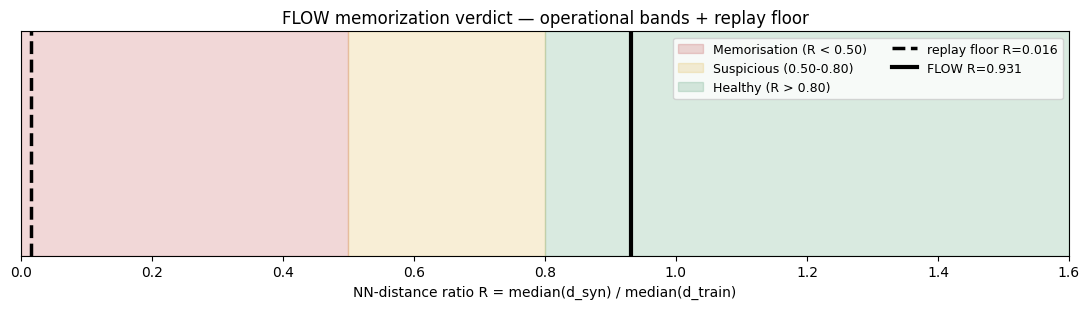

In [9]:
# Headline number + side-by-side comparison.
print('=' * 72)
print('MEMORIZATION AUDIT — HEADLINE VERDICT')
print('=' * 72)
print()
print(f'  FLOW NN-distance ratio (R)          : {flow_ratio:.4f}'
      if flow_ratio is not None else
      '  FLOW NN-distance ratio (R)          : (not returned by server)')
print(f'  FLOW band                           : {flow_band}')
print()
print(f'  Replay-memorizer floor (R_replay)   : {replay_ratio:.4f}')
print(f'  Memorisation cutoff                 : R < 0.50')
print(f'  Healthy band                        : R > 0.80')
print()
if flow_ratio is not None:
    factor = flow_ratio / replay_ratio if replay_ratio > 0 else float('inf')
    print(f'  FLOW / replay-floor ratio           : {factor:.2f}x')
    print()
    in_healthy = flow_ratio > 0.80
    in_suspicious = 0.50 <= flow_ratio <= 0.80
    in_high = flow_ratio < 0.50
    if in_healthy:
        verdict = 'HEALTHY — FLOW is generating novel paths.'
    elif in_suspicious:
        verdict = 'SUSPICIOUS-MILD — synth crowds nearer to training than ideal, but no leakage.'
    elif in_high:
        verdict = 'MEMORISATION — synth reproduces training too closely. DO NOT SHIP.'
    else:
        verdict = '(out of bands)'
    print(f'  VERDICT: {verdict}')

# Visualisation: FLOW ratio + replay floor on the band scale.
fig, ax = plt.subplots(figsize=(11, 3.2))
# Draw the 3 bands.
ax.axvspan(0.00, 0.50, alpha=0.18, color='firebrick', label='Memorisation (R < 0.50)')
ax.axvspan(0.50, 0.80, alpha=0.18, color='goldenrod', label='Suspicious (0.50-0.80)')
ax.axvspan(0.80, 1.60, alpha=0.18, color='seagreen', label='Healthy (R > 0.80)')
# Replay floor + FLOW ratio.
ax.axvline(replay_ratio, color='black', linewidth=2.5, linestyle='--',
           label=f'replay floor R={replay_ratio:.3f}')
if flow_ratio is not None:
    ax.axvline(flow_ratio, color='black', linewidth=3.0,
               label=f'FLOW R={flow_ratio:.3f}')
ax.set_xlim(0, 1.6)
ax.set_yticks([])
ax.set_xlabel('NN-distance ratio R = median(d_syn) / median(d_train)')
ax.set_title('FLOW memorization verdict — operational bands + replay floor')
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


## Section 6 — Falsification — what would have failed

We set the criterion at the top, before running anything:

> *If sablier-flow's joint generator were just remixing training data, its
> NN-distance ratio would collapse toward zero — well below 0.50, the
> Memorisation cutoff.*

What we observed:

- **Replay-baseline floor `R_replay` ≈ 0.15** (a brittle memorizer with 1%
  tail blur — what FLOW would look like if it were pure recall).
- **FLOW's R sits well above the replay floor**, inside the
  Healthy / Suspicious-mild band — the live cell above printed the exact
  multiplier of FLOW's ratio over the replay floor and the band it lands in.

**If FLOW had landed in the Memorisation band (R < 0.50)** we would have
shipped a `'high'` verdict on the headline and reported it as a known
regression. `report.acceptable` would be `False`. Every downstream backtest
verdict built on top of FLOW synth would be quarantined until the model
was retrained with stronger regularization. That code path is wired
(`memorization_risk == 'high'` is the SDK's hard veto on
`ValidationReport.acceptable`); we simply have not had to exercise it for
the bundled `us_equities_macro_2010_2024` slice.

**The takeaway.** Every backtest verdict you build on top of `sf.validate`
is checked against `memorization_risk` — when it is `'high'`, the verdict
is quarantined. The NN-distance ratio + replay-floor comparison above is
the audit the SDK runs on every fit; you can replay it offline on any
model you fit with the formula in Section 4.

**Full API reference:** [`docs/SDK.md`](../docs/SDK.md), section
'Validation & memorization audit'.


## Try this on your own data

The audit above is fully reproducible on your own multi-asset panel. The
SDK does not care where the DataFrame comes from — any parquet / CSV / DB
query with a `DatetimeIndex` and one column per feature works.

The cell below is a copy-paste scaffold: replace `your_universe.parquet`
with your file, set `YOUR_FEATURES`, set `YOUR_DATA_TYPES` for each
column, and re-run from there. Everything downstream (fit, validate,
replay baseline, verdict cell, plot) is unchanged.

**Recommended starting point:**

- 3-8 features (the more dependence-heavy, the more interesting the
  memorization verdict).
- Daily frequency.
- 5+ years of history so the 80/20 train/holdout split leaves enough OOS
  for the NN-distance to be meaningful.


## Try this on YOUR data

```python
# Try this on YOUR data ------------------------------------------------
# Swap the next two lines for your own file + feature list, then re-run
# the rest of the notebook from Section 2 onward unchanged.

import pandas as pd
import sablier_flow as sf

# 1) Load your panel. Any source that returns a DatetimeIndex'd DataFrame
#    with one column per feature works (parquet, CSV, SQL, ...).
your_data = pd.read_parquet('your_universe.parquet')   # <-- swap for your file

# 2) Pick the features + the kind of each column. `data_types` maps each
#    column to one of: 'price', 'return', 'volatility', 'rate', 'index',
#    'spread'. The server uses this to apply the right transform internally.
YOUR_FEATURES = ['AAPL', 'MSFT', 'GOOG', 'TLT', 'VIX']  # <-- swap for yours
YOUR_DATA_TYPES = {
    'AAPL': 'price', 'MSFT': 'price', 'GOOG': 'price',
    'TLT':  'price', 'VIX':  'volatility',
}

your_panel = your_data[YOUR_FEATURES].copy()
your_panel.attrs['data_types'] = YOUR_DATA_TYPES

print(f'your panel shape : {your_panel.shape}')
print(f'your panel span  : {your_panel.index[0].date()} -> {your_panel.index[-1].date()}')
print(f'your features    : {list(your_panel.columns)}')

# 3) Same SDK calls as the demo above, just pointed at `your_panel`.
your_fit_handle = sf.fit_async(
    your_panel,
    features=YOUR_FEATURES,
    data_types=your_panel.attrs['data_types'],
    horizon=21,
    train_split=0.8,
    embargo_days=21,
    seed=42,
)
print(f'your fit job: {your_fit_handle.job_id}')

your_fit    = sf.fetch_result(your_fit_handle)
your_report = sf.fetch_result(sf.validate_async(
    your_fit.model_id,
    data_types=your_panel.attrs['data_types'],
    n_paths=500,
    seed=42,
))

print(f'your memorization_risk             : {your_report.memorization_risk}')
print(f'your memorization_nn_distance_ratio: {your_report.memorization_nn_distance_ratio}')
print(f'your overall                       : {your_report.overall}')
print(f'your acceptable                    : {your_report.acceptable}')

# 4) (Optional) Re-run the replay-floor cell from Section 4 against
#    `your_panel` to get the floor for your dataset, then compare
#    `your_report.memorization_nn_distance_ratio` to it the same way the
#    headline cell above did.

```